# Enterprise Retail Sales & Customer Analytics Platform

## Exploratory Data Analysis (EDA)

### Objective
Analyze sales, profit, customer behavior, product performance, regional trends, and identify business insights using Python.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("clean_superstore.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State/Province,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Days
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,Texas,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512,4
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870,4
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717,4
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748,4
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,Pennsylvania,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840,7


In [3]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

- <b>Executive KPIs</b>

In [4]:
kpi = pd.DataFrame({
    "Metric": [
        "Total Sales",
        "Total Profit",
        "Total Orders",
        "Total Customers",
        "Average Order Value"
    ],
    "Value": [
        round(df["Sales"].sum(),2),
        round(df["Profit"].sum(),2),
        df["Order ID"].nunique(),
        df["Customer ID"].nunique(),
        round(df["Sales"].sum()/df["Order ID"].nunique(),2)
    ]
})

kpi

,Metric,Value
0,Total Sales,2326534.35
1,Total Profit,292296.81
2,Total Orders,5111.00
3,Total Customers,804.00
4,Average Order Value,455.20


- <b>Sales Analysis</b>

In [5]:
category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

category_sales

Category
Technology         839893.2790
Furniture          754747.7613
Office Supplies    731893.3140
Name: Sales, dtype: float64

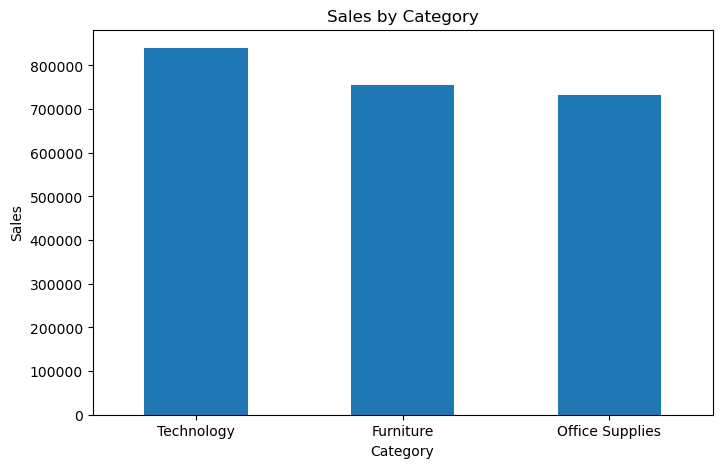

In [ ]:
plt.figure(figsize=(8,5))
category_sales.plot(kind="bar")
plt.title("Sales by Category")
plt.ylabel("Sales")
plt.xticks(rotation=0)

plt.show()

In [8]:
subcategory_sales = (
    df.groupby("Sub-Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

subcategory_sales.head(10)

Sub-Category
Chairs         335768.2490
Phones         331842.6400
Storage        224644.5540
Tables         208020.1820
Binders        207354.8810
Machines       189925.0310
Accessories    167380.3180
Copiers        150745.2900
Bookcases      115361.2043
Appliances     108213.1850
Name: Sales, dtype: float64

In [9]:
top_products = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

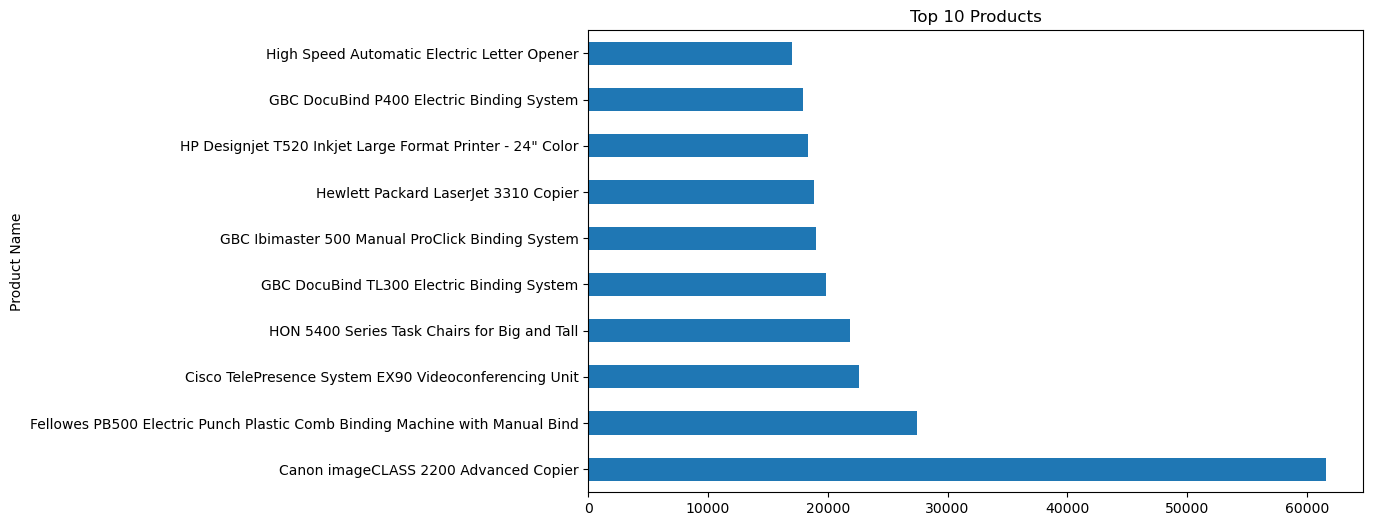

In [10]:
plt.figure(figsize=(10,6))

top_products.plot(kind="barh")

plt.title("Top 10 Products")

plt.show()

- <b>Customer Analysis</b>

In [11]:
top_customers = (
    df.groupby("Customer Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_customers

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64

In [12]:
segment = (
    df.groupby("Segment")
      .agg(
          Sales=("Sales","sum"),
          Profit=("Profit","sum")
      )
)

segment

,Sales,Profit
Segment,,
Consumer,1.170660e+06,136371.4463
Corporate,7.158061e+05,94249.6400
Home Office,4.400684e+05,61675.7283


- <b>Region Analysis</b>

In [13]:
region = (
    df.groupby("Region")
      .agg(
          Sales=("Sales","sum"),
          Profit=("Profit","sum")
      )
      .sort_values("Sales",ascending=False)
)

region

,Sales,Profit
Region,,
West,739813.6085,110798.8170
East,691828.1680,94883.2603
Central,503170.6728,39865.3070
South,391721.9050,46749.4303


In [23]:
print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City', 'State/Province', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Days']


In [25]:
state = (
    df.groupby("State/Province")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

state

State/Province
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Florida          89473.7080
Illinois         80166.1010
Ohio             78258.1360
Michigan         76269.6140
Virginia         70636.7200
Name: Sales, dtype: float64

- <b>Time Series Analysis</b>

In [16]:
monthly_sales = (
    df.groupby(df["Order Date"].dt.to_period("M"))["Sales"]
      .sum()
)

monthly_sales

Order Date
2023-01     14518.0550
2023-02      4519.8920
2023-03     56933.9090
2023-04     28295.3450
2023-05     26319.7670
2023-06     34669.4796
2023-07     33946.3930
2023-08     28918.3385
2023-09     82670.4288
2023-10     32413.3390
2023-11     78826.9567
2023-12     72008.3085
2024-01     18461.9156
2024-02     11951.4110
2024-03     39978.6280
2024-04     34195.2085
2024-05     30246.9465
2024-06     24797.2920
2024-07     28765.3250
2024-08     37057.0042
2024-09     64627.0460
2024-10     31407.1335
2024-11     75972.5635
2024-12     75532.5572
2025-01     18830.3310
2025-02     22978.8150
2025-03     53031.0690
2025-04     38829.1590
2025-05     57042.8380
2025-06     40937.1480
2025-07     40300.4990
2025-08     31716.8143
2025-09     73521.6629
2025-10     59831.0010
2025-11     79411.9658
2025-12     97502.2770
2026-01     44259.2140
2026-02     20301.1334
2026-03     60728.4808
2026-04     36779.0361
2026-05     45155.4822
2026-06     53056.0777
2026-07     45989.4960


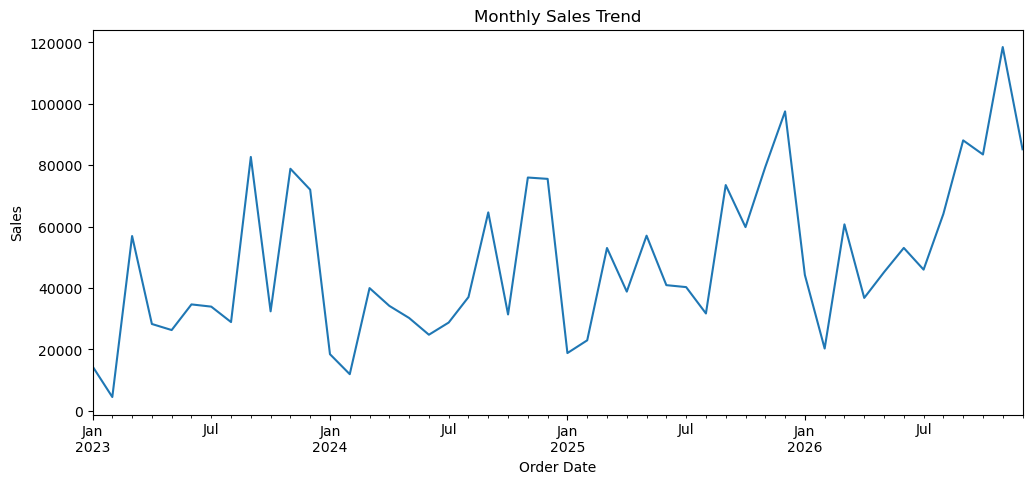

In [17]:
plt.figure(figsize=(12,5))

monthly_sales.plot()

plt.title("Monthly Sales Trend")

plt.ylabel("Sales")

plt.show()

- <b>Profit Analysis</b>

In [18]:
loss = df[df["Profit"] < 0]
loss.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State/Province,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Days
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870,4
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748,4
14,15,US-2023-105417,2023-01-07,2023-01-12,Standard Class,VS-21820,Vivek Sundaresam,Consumer,United States,Huntsville,Texas,77340,Central,FUR-FU-10004864,Furniture,Furnishings,"Howard Miller 14-1/2"" Diameter Chrome Round Wa...",76.728,3,0.6,-53.7096,5
15,16,US-2023-105417,2023-01-07,2023-01-12,Standard Class,VS-21820,Vivek Sundaresam,Consumer,United States,Huntsville,Texas,77340,Central,OFF-BI-10003708,Office Supplies,Binders,Acco Four Pocket Poly Ring Binder with Label H...,10.430,7,0.8,-18.2525,5
24,25,US-2023-118192,2023-01-13,2023-01-18,Standard Class,MM-17920,Michael Moore,Consumer,United States,Newark,Ohio,43055,East,OFF-BI-10003476,Office Supplies,Binders,Avery Metallic Poly Binders,3.438,2,0.7,-2.5212,5


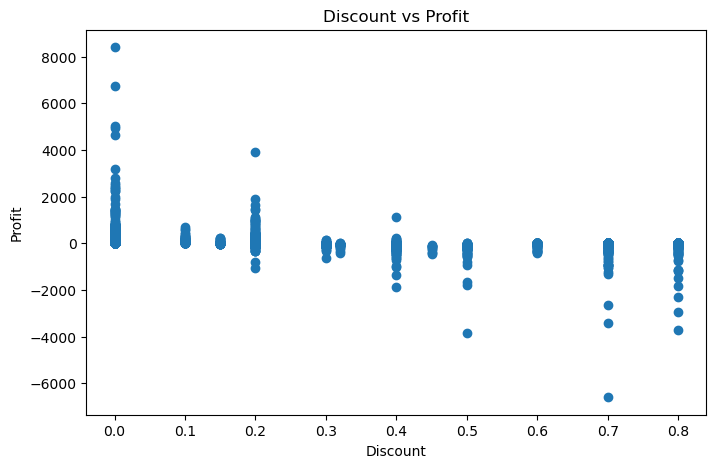

In [19]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Discount"],
    df["Profit"]
)

plt.title("Discount vs Profit")

plt.xlabel("Discount")

plt.ylabel("Profit")

plt.show()

- <b>Shipping Analysis</b>

In [20]:
df["Shipping Days"].mean()

np.float64(3.9613498136158523)

In [21]:
ship = (
    df.groupby("Ship Mode")
      .agg(
          Orders=("Order ID","count"),
          Sales=("Sales","sum")
      )
)

ship

,Orders,Sales
Ship Mode,,
First Class,1548,3.517507e+05
Same Day,547,1.292720e+05
Second Class,1979,4.666711e+05
Standard Class,6120,1.378841e+06


- <b>Final Business Insights</b>

In [22]:
print("Top Category :", category_sales.idxmax())

print("Top Region :", region["Sales"].idxmax())

print("Top Customer :", top_customers.idxmax())

print("Highest Selling State :", state.idxmax())

print("Average Shipping Days :", round(df["Shipping Days"].mean(),2))

Top Category : Technology
Top Region : West
Top Customer : Sean Miller


NameError: name 'state' is not defined